## Code for all transitions analysis

In [1]:
import numpy as np
import xarray as xr
import itertools
from itertools import product
import hexMinisom
import matplotlib.pyplot as plt
import pickle
from sammon import sammon
import itertools
import igraph as ig
import colorsys
import random
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.feature as cf
from scipy import stats

In [2]:
# ============================================================
# Hex-grid utilities (oddr -> cube distance)
# ============================================================

def oddr_to_cube(row, col):
    """
    Convert odd-r horizontal layout (row, col) to cube coordinates.
    Uses integer math for stable integer distances.
    """
    row = int(row)
    col = int(col)
    q = col - (row - (row & 1)) // 2
    r = row
    return (q, r, -q - r)


def _get_rowcol(node):
    """
    Supports either:
      (row, col)
      ((row, col), meta)
    Returns:
      (row, col) as ints
    """
    # Case 1: (row, col)
    if isinstance(node, (tuple, list)) and len(node) == 2 and np.isscalar(node[0]) and np.isscalar(node[1]):
        return int(node[0]), int(node[1])

    # Case 2: ((row, col), meta)
    if (
        isinstance(node, (tuple, list)) and len(node) == 2
        and isinstance(node[0], (tuple, list)) and len(node[0]) == 2
    ):
        return int(node[0][0]), int(node[0][1])

    raise TypeError(f"Unrecognized node format: {node}")


def calc_transition_distance(s, e):
    """
    Hex distance between two nodes.
    Accepts either (row,col) or ((row,col),meta) for s/e.
    Returns an int.
    """
    sr, sc = _get_rowcol(s)
    er, ec = _get_rowcol(e)

    s_cube = oddr_to_cube(sr, sc)
    e_cube = oddr_to_cube(er, ec)

    dist = (
        abs(s_cube[0] - e_cube[0]) +
        abs(s_cube[1] - e_cube[1]) +
        abs(s_cube[2] - e_cube[2])
    ) // 2

    return int(dist)


# ============================================================
# I/O utilities
# ============================================================

def save_som(som, fileName):
    with open(fileName, "wb") as outfile:
        pickle.dump(som, outfile, protocol=pickle.HIGHEST_PROTOCOL)


def load_som(fileName):
    with open(fileName, "rb") as infile:
        som = pickle.load(infile)
    return som


# ============================================================
# Transition probability helper
# ============================================================

def calculate_transition_probabilities(transitions, probabilities, default=0.0):
    """
    transitions: array-like of shape (n,2,2) with ((r,c),(r,c))
    probabilities: dict-of-dicts probs[src][dst] = p
    """
    prob_list = []
    for t in transitions:
        src = (t[0][0], t[0][1])
        dst = (t[1][0], t[1][1])
        p = probabilities.get(src, {}).get(dst, default)
        prob_list.append(p)
    return prob_list


# ============================================================
# Season splitting
# ============================================================

def split_seasons_by_occurance(idxs):
    """
    idxs: 1D array-like of time indices for a given season across many years.
    Returns a list of arrays, each array is one contiguous season occurrence.
    """
    idxs = np.asarray(idxs)
    if idxs.size == 0:
        return []
    idxs = np.sort(idxs)

    split_indices = np.where(np.diff(idxs) > 1)[0] + 1
    return np.split(idxs, split_indices)


# ============================================================
# Transition extraction (works for seasonal and annual)
# ============================================================

def calculate_transitions_over_segments(
    winners,
    segments,
    self_transitions=False,
    node_event_length=None
):
    """
    General transition calculator that works for BOTH seasonal and annual,
    as long as you provide "segments".

    winners:
      array-like of daily SOM winners (each element like (row,col))
    segments:
      list of index arrays; each array selects a contiguous time segment
      (e.g., each DJF occurrence; or one segment containing all days)
    self_transitions:
      - False: remove A->A transitions at daily level (when node_event_length is None)
      - True: keep A->A transitions
    node_event_length:
      - None: no event-length filtering
      - int: keep transition if origin OR destination node-event lasted >= node_event_length
             Event length computed from consecutive runs inside each segment.
             This branch preserves daily self transitions if self_transitions=True.
    Returns:
      transitions: np array (n_unique, 2, 2)
      tcounts: np array (n_unique,)
      transitionCounts: dict-of-dicts counts[src][dst]=count
      transitionProbs: dict-of-dicts probs[src][dst]=prob
      transitions_list: list of ((src),(dst)) daily transitions that were included
    """
    winners_np = np.asarray(winners)
    transitions_list = []

    for seg_idxs in segments:
        seg_idxs = np.asarray(seg_idxs)
        if seg_idxs.size < 2:
            continue

        s_winners = winners_np[seg_idxs]
        s_winners = [tuple(row) for row in s_winners]

        # ------------------------------------------------------------
        # CASE 1: no node-event filtering
        # ------------------------------------------------------------
        if node_event_length is None:
            if not self_transitions:
                # collapse consecutive repeats to remove daily self transitions
                s_winners = [k for k, _g in itertools.groupby(s_winners)]

            if len(s_winners) >= 2:
                transitions_list.extend(list(itertools.pairwise(s_winners)))
            continue

        # ------------------------------------------------------------
        # CASE 2: node_event_length filtering (preserve self transitions if requested)
        # ------------------------------------------------------------
        run_len_by_day = np.zeros(len(s_winners), dtype=int)

        start = 0
        for k, g in itertools.groupby(s_winners):
            run_len = sum(1 for _ in g)
            run_len_by_day[start:start + run_len] = run_len
            start += run_len

        daily_transitions = list(itertools.pairwise(s_winners))

        for j, (a, b) in enumerate(daily_transitions):
            origin_len = run_len_by_day[j]
            dest_len = run_len_by_day[j + 1]

            if (origin_len >= node_event_length) or (dest_len >= node_event_length):
                if self_transitions or (a != b):
                    transitions_list.append((a, b))

    # ------------------------------------------------------------
    # Aggregate counts + probabilities
    # ------------------------------------------------------------
    if len(transitions_list) == 0:
        transitions = np.empty((0, 2, 2), dtype=int)
        tcounts = np.array([], dtype=int)
        transitionCounts = {}
        transitionProbs = {}
        return transitions, tcounts, transitionCounts, transitionProbs, transitions_list

    transitions, tcounts = np.unique(transitions_list, return_counts=True, axis=0)

    transitionCounts, transitionProbs = build_transition_dicts(transitions, tcounts)

    return transitions, tcounts, transitionCounts, transitionProbs, transitions_list


def build_transition_dicts(transitions, tcounts):
    """
    Build dict-of-dicts count and prob maps from:
      transitions: np array (n_unique, 2, 2) of ((r,c),(r,c))
      tcounts:     np array (n_unique,) counts aligned with transitions

    Returns:
      transitionCounts[src][dst] = count
      transitionProbs[src][dst]  = probability among outgoing transitions from src
    """
    transitionCounts = {}
    transitionProbs = {}

    if transitions.shape[0] == 0:
        return transitionCounts, transitionProbs

    # collect unique source nodes
    sources = [tuple(x) for x in transitions[:, 0, :]]
    unique_sources = sorted(set(sources))

    for src in unique_sources:
        mask = (transitions[:, 0, 0] == src[0]) & (transitions[:, 0, 1] == src[1])

        if not np.any(mask):
            transitionCounts[src] = {}
            transitionProbs[src] = {}
            continue

        dst_nodes = [tuple(x) for x in transitions[mask, 1, :]]
        cnts = [int(x) for x in tcounts[mask]]

        total = int(np.sum(cnts))
        probs = [(c / total) for c in cnts] if total > 0 else [0.0] * len(cnts)

        transitionCounts[src] = dict(zip(dst_nodes, cnts))
        transitionProbs[src] = dict(zip(dst_nodes, probs))

    return transitionCounts, transitionProbs


# ============================================================
# Significance testing with self-transition highlighting
# ============================================================

def precompute_neighbors_with_self(nodes):
    """
    Precompute candidate destinations for each node:
      dist in {0,1} (self + adjacent)
    Returns:
      dict node -> list of candidate nodes
    """
    nodes = list(nodes)
    neigh = {}
    for node in nodes:
        neigh[node] = [node_end for node_end in nodes if calc_transition_distance(node, node_end) in (0, 1)]
    return neigh


def calc_transition_significance_with_self(
    counts_dict,
    nodes,
    percentile=0.99,
    iters=1000,
    neighbors_with_self=None
):
    """
    counts_dict: dict-of-dicts {src_node: {dst_node: count}}
    nodes: list of all nodes to consider (typically node_indices)
    percentile: 0.99 => 99th percentile
    iters: bootstrap iterations
    neighbors_with_self:
      optional precomputed dict node->candidates (self+adjacent)

    Null hypothesis:
      given n transitions among candidate destinations, destinations are uniform over candidates.
    Returns:
      sig_edges_coord: list of ((src),(dst)) significant NON-self edges
      sig_self_nodes: set of src nodes with significant self-transition
    """
    sig_edges_coord = []
    sig_self_nodes = set()

    threshold = 100.0 * float(percentile)  # percentileofscore returns 0..100

    nodes = list(nodes)
    if neighbors_with_self is None:
        neighbors_with_self = precompute_neighbors_with_self(nodes)

    for src in nodes:
        candidates = neighbors_with_self.get(src, [])
        if not candidates:
            continue

        out_counts = counts_dict.get(src, {})
        if not out_counts:
            continue

        # observed transitions restricted to candidate destinations
        n = sum(cnt for dst, cnt in out_counts.items() if dst in candidates)
        if n <= 0:
            continue

        # null distributions per candidate
        null_counts = {dst: [] for dst in candidates}

        for _ in range(iters):
            samples = {dst: 0 for dst in candidates}

            for _ in range(n):
                dst = random.choice(candidates)
                samples[dst] += 1

            for dst in candidates:
                null_counts[dst].append(samples[dst])

        for dst in candidates:
            obs = out_counts.get(dst, 0)
            pct = stats.percentileofscore(null_counts[dst], obs)

            if pct >= threshold:
                if dst == src:
                    sig_self_nodes.add(src)
                else:
                    sig_edges_coord.append((src, dst))

    return sig_edges_coord, sig_self_nodes


# ============================================================
# Converting significant transitions to igraph edges/weights
# ============================================================

def subset_transitions_counts(trans_universe, sig_edges_coord, trans_counts):
    """
    trans_universe: np array (n,2,2) transitions (e.g., sub_transitions)
    sig_edges_coord: list of ((src),(dst)) in coordinate form
    trans_counts: dict-of-dicts counts[src][dst]=count

    Returns:
      ig_edges:   list of (src_idx, dst_idx)
      ig_weights: list of counts aligned with ig_edges
    """
    sig_set = set(sig_edges_coord)

    ig_edges = []
    ig_weights = []

    # precompute node->index to avoid repeated .index calls
    node_to_idx = {node: i for i, node in enumerate(node_indices)}

    for (s, e) in trans_universe:
        s_t = tuple(s)
        e_t = tuple(e)

        if (s_t, e_t) in sig_set:
            ig_edges.append((node_to_idx[s_t], node_to_idx[e_t]))
            ig_weights.append(int(trans_counts.get(s_t, {}).get(e_t, 0)))

    return ig_edges, ig_weights


def build_sig_plot_data(
    counts_dict,
    nodes,
    trans_universe,
    outline_color="#ff00ff",
    default_outline="#000000",
    outline_width_sig=4,
    outline_width_default=1,
    percentile=0.99,
    iters=1000,
    neighbors_with_self=None
):
    """
    Works for BOTH annual and seasonal.

    counts_dict: dict-of-dicts counts[src][dst]=count
      - annual example: subset_transitionCounts
      - seasonal example: DJF_tcounts, etc.
    nodes: list of all SOM nodes (typically node_indices)
    trans_universe: transitions array used for plotting (e.g., sub_transitions)

    Returns:
      sig_edges: list of (src_idx, dst_idx) edges for igraph
      sig_weights: list of weights aligned with sig_edges
      vertex_frame_color: per-node outline color (self-significance)
      vertex_frame_width: per-node outline width (self-significance)
      sig_self_nodes: set of nodes whose self transition is significant
    """
    sig_edges_coord, sig_self_nodes = calc_transition_significance_with_self(
        counts_dict=counts_dict,
        nodes=nodes,
        percentile=percentile,
        iters=iters,
        neighbors_with_self=neighbors_with_self
    )

    sig_edges, sig_weights = subset_transitions_counts(
        trans_universe=trans_universe,
        sig_edges_coord=sig_edges_coord,
        trans_counts=counts_dict
    )

    vertex_frame_color = []
    vertex_frame_width = []

    for n in nodes:
        if n in sig_self_nodes:
            vertex_frame_color.append(outline_color)
            vertex_frame_width.append(outline_width_sig)
        else:
            vertex_frame_color.append(default_outline)
            vertex_frame_width.append(outline_width_default)

    return sig_edges, sig_weights, vertex_frame_color, vertex_frame_width, sig_self_nodes


# ============================================================
# Color utility
# ============================================================

def generate_distinct_colors(n, shuffle=True):
    """
    Generate n visually distinct colors using HSV.
    """
    if n <= 0:
        return []

    colors = []
    for i in range(n):
        hue = i / n
        saturation = 1.0
        value = 1.0
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)
        rgb = [int(x * 255) for x in rgb]
        hex_color = f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"
        colors.append(hex_color)

    if shuffle:
        random.shuffle(colors)

    return colors


# ============================================================
# Convenience: build annual subset dicts from (sub_transitions, sub_tcounts)
# ============================================================

def build_subset_transition_dicts(sub_transitions, sub_tcounts, nodes):
    """
    Creates:
      subset_transitionCounts[src][dst] = count
      subset_transitionProbs[src][dst]  = probability among outgoing from src

    This version is robust to nodes with no outgoing transitions and keeps ints clean.
    """
    subset_transitionProbs = {}
    subset_transitionCounts = {}

    # precompute masks per src (faster if you call repeatedly)
    for node in nodes:
        mask = (sub_transitions[:, 0, 0] == node[0]) & (sub_transitions[:, 0, 1] == node[1])

        if not np.any(mask):
            subset_transitionProbs[node] = {}
            subset_transitionCounts[node] = {}
            continue

        transitionKeys = [tuple(x) for x in sub_transitions[mask, 1, :]]
        transitionCnt = [int(x) for x in sub_tcounts[mask]]

        total = int(np.sum(transitionCnt))
        probabilities = [(c / total) for c in transitionCnt] if total > 0 else [0.0] * len(transitionCnt)

        subset_transitionProbs[node] = dict(zip(transitionKeys, probabilities))
        subset_transitionCounts[node] = dict(zip(transitionKeys, transitionCnt))

    return subset_transitionCounts, subset_transitionProbs

def safe_frac(dist_counts, d=6):
    denom = sum(dist_counts.values())
    return dist_counts[d] / denom if denom > 0 else np.nan

def add_igraph_example_transition_axis(
    fig,
    bbox=(0.86, 0.40, 0.13, 0.20),   # [left, bottom, width, height] in figure coords
    y_example=((50, 60), (60, 50)),  # SAME coord space as your Sammon y
    blue_to_red=200,
    red_to_blue=50,
    size_scale=0.18,                # use SAME scaling as your seasonal plots
    example_vertex_weight=125,
    curved_amount=0.35,             # tweak to match screenshot
    box_pad=2.0                     # extra padding in data coords for the border
):
    """
    Adds a single standalone 'Example Transition' axis, using igraph to keep scaling consistent.
    """

    ax = fig.add_axes(list(bbox))
    ax.set_axis_off()

    # --- Build a 2-node directed graph with 2 edges (both directions)
    # Node 0 = RED (upper-left), Node 1 = BLUE (lower-right)
    g_ex = ig.Graph(n=2, edges=[(1, 0), (0, 1)], directed=True)

    # Layout in SAME coordinate system as your Sammon embedding
    coords = np.array(y_example, dtype=float)  # [[50,60],[60,50]]
    layout_ex = ig.Layout(coords=coords.tolist())

    # Vertex/edge styling (keep scaling consistent)
    vertexWeights_ex = [example_vertex_weight, example_vertex_weight]
    vertexColors_ex  = ["#ff0000", "#0000ff"]  # red, blue

    # Edge weights: blue->red thick, red->blue thin
    edgeWeights_ex = [blue_to_red, red_to_blue]

    # Edge colors aligned with edges list above:
    # edges=[(1,0),(0,1)] -> (blue->red) is BLUE; (red->blue) is RED
    edgeColors_ex = ["#0000ff", "#ff0000"]

    # Curvature: separate the two directions
    edgeCurved_ex = [curved_amount, -curved_amount]

    # Plot with igraph onto this axis
    ig.plot(
        g_ex,
        target=ax,
        layout=layout_ex,
        vertex_size=[v * size_scale for v in vertexWeights_ex],
        vertex_color=vertexColors_ex,
        edge_width=[w * size_scale for w in edgeWeights_ex],
        edge_color=edgeColors_ex,
        edge_curved=edgeCurved_ex,
        edge_arrow_size=0,   # removes arrowheads for the screenshot look
        margin=20
    )

    # ------------------------------------------------------------
    # Add border + text using matplotlib (in DATA COORDS)
    # ------------------------------------------------------------
    x0, y0 = coords.min(axis=0)
    x1, y1 = coords.max(axis=0)

    # Expand a bit so text fits
    x0b, x1b = x0 - box_pad, x1 + box_pad + 25
    y0b, y1b = y0 - box_pad - 10, y1 + box_pad + 10

    # Border box (matches your screenshot)
    ax.plot([x0b, x0b, x1b, x1b, x0b],
            [y1b, y0b, y0b, y1b, y1b],
            color="k", linewidth=1.5)

    # Title + labels (placed like screenshot)
    ax.text((x0b + x1b) / 2, y1b - 2, "Example Transition",
            ha="center", va="top", fontsize=14)

    ax.text(x0b + 2, (y0b + y1b) / 2 - 2,
            f"{blue_to_red} transitions\nfrom blue to red",
            ha="left", va="center", fontsize=12)

    ax.text(x1b - 2, (y0b + y1b) / 2 + 6,
            f"{red_to_blue} transitions\nfrom red to blue",
            ha="right", va="center", fontsize=12)

    return ax

#### Read in our data

In [3]:
dataset = xr.open_dataarray('/glade/work/molina/DATA/Z500Anoms_ERA5.nc')

latSlice = slice(20, 80) #20N, 80N
lonSlice = slice(180, 330) #180W, 30W
dataarray = dataset.sel(lat=latSlice, lon=lonSlice)
dataarray = dataarray.stack(latlon=['lat', 'lon']).values

# Seasonal breakdown of the data
DJF = dataset.time.dt.month.isin([12, 1, 2])
DJF_idxs = np.array(DJF).nonzero()[0]
MAM = dataset.time.dt.month.isin([3, 4, 5])
MAM_idxs = np.array(MAM).nonzero()[0]
JJA = dataset.time.dt.month.isin([6, 7, 8])
JJA_idxs = np.array(JJA).nonzero()[0]
SON = dataset.time.dt.month.isin([9, 10, 11])
SON_idxs = np.array(SON).nonzero()[0]

print(dataarray.shape)

(30660, 9211)


#### Load in our SOM

In [4]:
som = load_som('SOM40.p')

# Normalize mask to boolean: True=masked, False=active
mask = np.asarray(som._mask).astype(bool)

# Active node coordinates
node_indices_xy = np.where(~mask)
node_indices = list(zip(node_indices_xy[0], node_indices_xy[1]))

inputLength = dataarray.shape[1]

winmap = som.win_map(dataarray, return_indices=True)

# List of regimes for each day in order
neuronList = [som.winner(x) for x in dataarray]

# Weights bounds (symmetric around 0)
w = som._weights
minimum_weight = -np.max(np.abs(w))
maximum_weight = np.max(np.abs(w))

# Assign node numbers only for active nodes
node_nums = {}
n_counter = 1
for i in range(mask.shape[0])[::-1]:
    for j in range(mask.shape[1]):
        if not mask[i, j]:
            node_nums[(i, j)] = n_counter
            n_counter += 1

color_list = generate_distinct_colors(len(node_indices))

#### Calculate our transitions

In [5]:
# ------------------------------------------------------------
# Annual subset transitions with node_event_length >= 3
# INCLUDING self-transitions (A -> A)
# ------------------------------------------------------------

node_event_length = 3
self_transitions = True

# Compute run lengths per day for the full annual sequence
winners = [tuple(x) for x in neuronList]

run_len_by_day = np.zeros(len(winners), dtype=int)
start = 0
for k, g in itertools.groupby(winners):
    run_len = sum(1 for _ in g)
    run_len_by_day[start:start + run_len] = run_len
    start += run_len

# Daily transitions (includes A->A)
daily_transitions = list(itertools.pairwise(winners))

subset_transitions_list = []
for j, (a, b) in enumerate(daily_transitions):
    origin_len = run_len_by_day[j]
    dest_len = run_len_by_day[j + 1]

    if (origin_len >= node_event_length) or (dest_len >= node_event_length):
        if self_transitions or (a != b):
            subset_transitions_list.append((a, b))

# Unique transition counts
if len(subset_transitions_list) == 0:
    sub_transitions = np.empty((0, 2, 2), dtype=int)
    sub_tcounts = np.array([], dtype=int)
else:
    sub_transitions, sub_tcounts = np.unique(subset_transitions_list, return_counts=True, axis=0)
    sub_tcounts = sub_tcounts.astype(int)

# Build per-node dicts
subset_transitionProbs = {}
subset_transitionCounts = {}

for node in node_indices:
    if sub_transitions.shape[0] == 0:
        subset_transitionProbs[node] = {}
        subset_transitionCounts[node] = {}
        continue

    mask = (sub_transitions[:, 0, 0] == node[0]) & (sub_transitions[:, 0, 1] == node[1])

    if not np.any(mask):
        subset_transitionProbs[node] = {}
        subset_transitionCounts[node] = {}
        continue

    transitionKeys = [tuple(x) for x in sub_transitions[mask, 1, :]]
    transitionCnt = [int(x) for x in sub_tcounts[mask]]

    total = int(np.sum(transitionCnt))
    probabilities = [(c / total) for c in transitionCnt] if total > 0 else [0.0] * len(transitionCnt)

    subset_transitionProbs[node] = dict(zip(transitionKeys, probabilities))
    subset_transitionCounts[node] = dict(zip(transitionKeys, transitionCnt))

### Calculate our seasonal transitions

In [6]:
split_DJF = split_seasons_by_occurance(DJF_idxs)
split_MAM = split_seasons_by_occurance(MAM_idxs)
split_JJA = split_seasons_by_occurance(JJA_idxs)
split_SON = split_seasons_by_occurance(SON_idxs)

DJF_transitions, DJF_rawcounts, DJF_tcounts, DJF_tprobs, DJF_tlist = calculate_transitions_over_segments(
    winners=neuronList,
    segments=split_DJF,
    self_transitions=True,
    node_event_length=3
)

MAM_transitions, MAM_rawcounts, MAM_tcounts, MAM_tprobs, MAM_tlist = calculate_transitions_over_segments(
    winners=neuronList,
    segments=split_MAM,
    self_transitions=True,
    node_event_length=3
)

JJA_transitions, JJA_rawcounts, JJA_tcounts, JJA_tprobs, JJA_tlist = calculate_transitions_over_segments(
    winners=neuronList,
    segments=split_JJA,
    self_transitions=True,
    node_event_length=3
)

SON_transitions, SON_rawcounts, SON_tcounts, SON_tprobs, SON_tlist = calculate_transitions_over_segments(
    winners=neuronList,
    segments=split_SON,
    self_transitions=True,
    node_event_length=3
)

In [7]:
# ------------------------------------------------------------
# Calculate the Sammon mapping of the nodes for displaying node transitions
# ------------------------------------------------------------

# gets the weights of each node into the order of node_indices
weights = som.get_weights()[node_indices_xy[0], node_indices_xy[1]]

# Run the Sammon projection (y has shape (n_nodes, 2))
y, E = sammon(weights, 2, display=1)
y = np.asarray(y)

# ------------------------------------------------------------
# Rotate and flip the points to be oriented the same as other figures
# ------------------------------------------------------------

# NOTE: 2*pi/7 is ~51.4 degrees. If you truly want ~60 degrees, use np.pi/3 instead.
theta = 2 * np.pi / 7

rotation_matrix = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

# rotate
y = y @ rotation_matrix.T

# center and flip x-axis (stable orientation)
y = y - y.mean(axis=0)
y[:, 0] *= -1

TolFun exceeded: Optimisation terminated


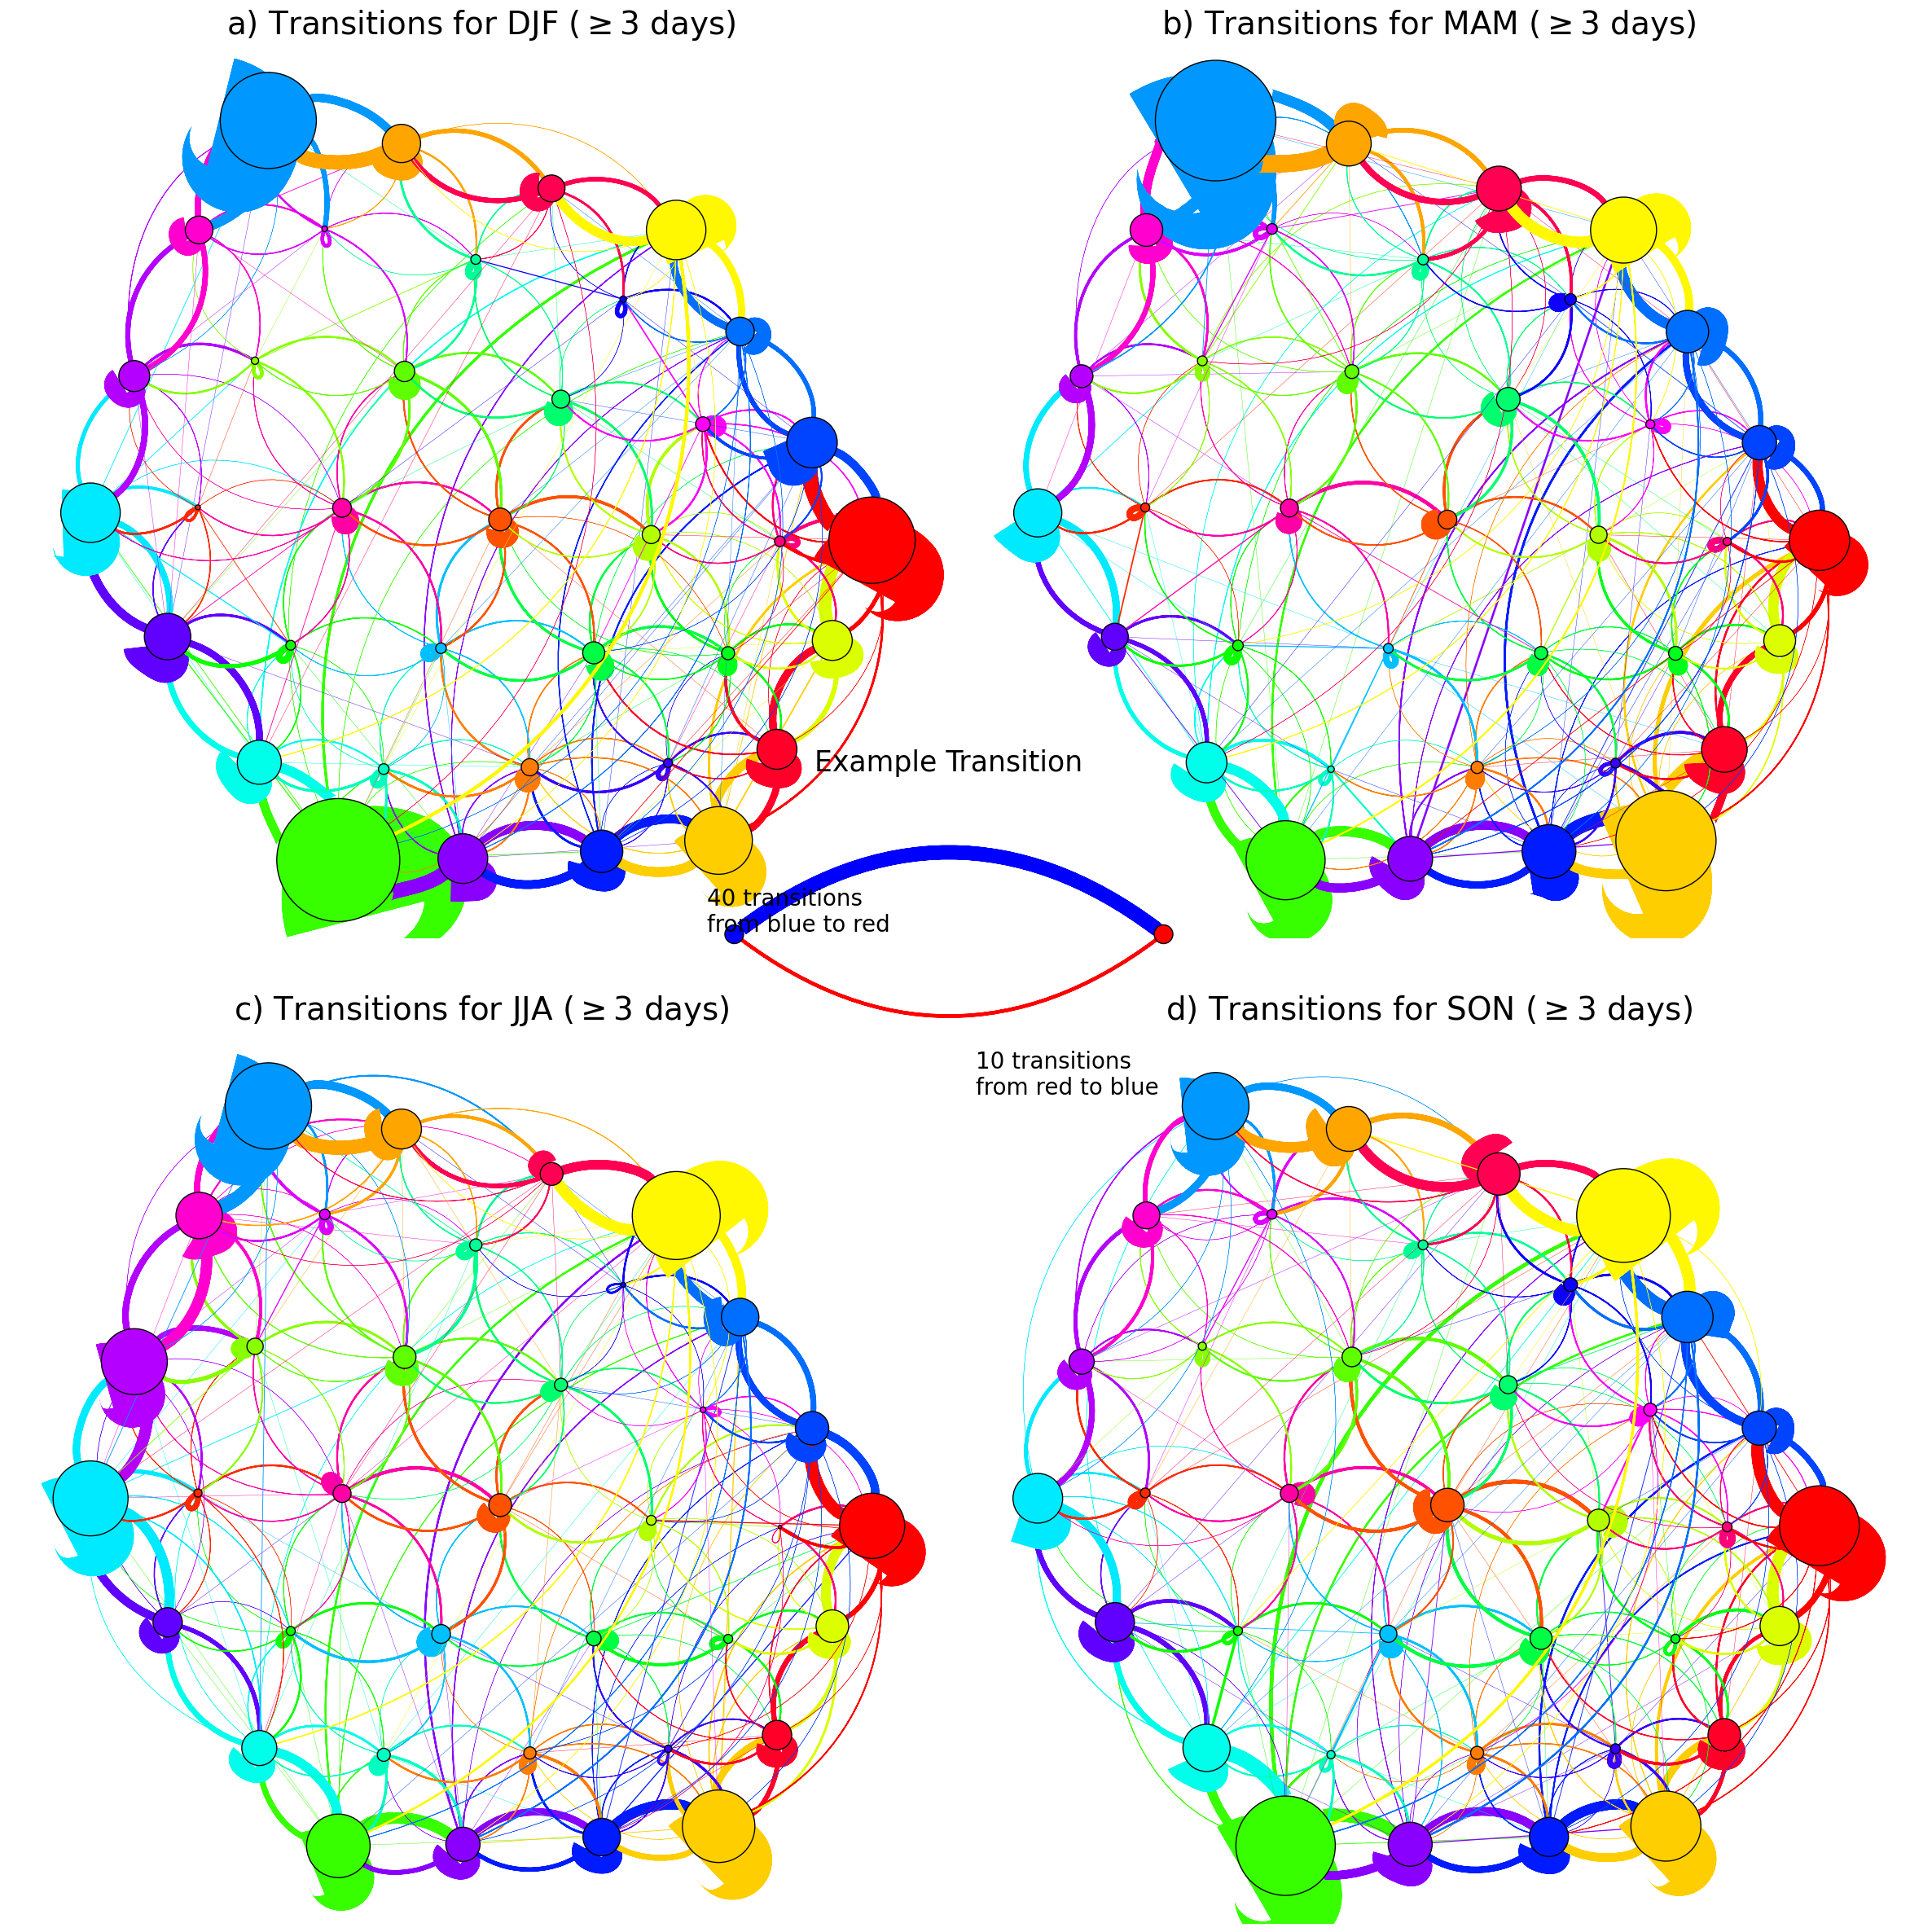

In [8]:
# ------------------------------------------------------------
# Seasonal subset transitions (>=3 days) plotting
# with SAFE indexing + consistent scaling + global inset example
# ------------------------------------------------------------

# Pack your seasonal results (from calculate_transitions_over_segments(..., node_event_length=3))
seasonal_transitions = [
    ("DJF", DJF_transitions, DJF_rawcounts, DJF_tcounts),
    ("MAM", MAM_transitions, MAM_rawcounts, MAM_tcounts),
    ("JJA", JJA_transitions, JJA_rawcounts, JJA_tcounts),
    ("SON", SON_transitions, SON_rawcounts, SON_tcounts),
]
subplot_title = ["a) ", "b) ", "c) ", "d) "]

# Precompute node -> index mapping for speed and safety
node_to_idx = {node: i for i, node in enumerate(node_indices)}

fig, axs = plt.subplots(2, 2, figsize=(30, 30))

for i, (season_name, trans_arr, rawcounts_arr, counts_dict) in enumerate(seasonal_transitions):
    ax = axs[i // 2, i % 2]

    n_vertices = len(node_indices)

    # Ensure edges are igraph indices (src_idx, dst_idx)
    # trans_arr is expected shape (n_unique, 2, 2) like: [[(r,c),(r,c)], ...]
    edges = [(node_to_idx[tuple(s)], node_to_idx[tuple(e)]) for s, e in trans_arr]

    # Edge weights (ensure python ints)
    edgeWeights = [int(w) for w in rawcounts_arr]  # rawcounts_arr aligns with trans_arr

    # Vertex weights from dict-of-dicts (safe .get)
    vertexWeights = [sum(counts_dict.get(n, {}).values()) for n in node_indices]

    vertexColors = list(color_list)

    # Edge color is the same as the node it originates from
    edgeColors = [color_list[s] for s, e in edges]

    g = ig.Graph(n_vertices, edges)
    layout = ig.Layout(coords=y)

    geqstuff = r"($\geq3$ days)"
    ax.set_title(
        f"{subplot_title[i]}Transitions for {season_name} {geqstuff}",
        fontsize=28
    )

    ig.plot(
        g,
        target=ax,
        layout=layout,
        vertex_size=[v * 0.18 * 1.75 for v in vertexWeights],
        vertex_color=vertexColors,
        edge_width=[w * 0.18 * 1.75 for w in edgeWeights],
        edge_color=edgeColors
    )

plt.subplots_adjust(wspace=0.001, hspace=0.1)

# ============================================================
# GLOBAL FIGURE-CORD EXAMPLE TRANSITION (inset axis)
# ============================================================

# [left, bottom, width, height] in FIGURE coords (0–1)
example_ax = fig.add_axes([0.40, 0.425, 0.22, 0.18])  # tweak to taste
example_ax.set_axis_off()

# Tiny 2-node example graph
g_ex = ig.Graph(2, [(0, 1), (1, 0)])
layout_ex = ig.Layout(coords=[[0, 0], [1, 0]])

vertexColors_ex = ["#0000ff", "#ff0000"]  # blue, red
edgeColors_ex = ["#0000ff", "#ff0000"]    # blue->red, red->blue

vertexWeights_ex = [75, 75]
edgeWeights_ex = [40, 10]  # blue->red heavier than red->blue

ig.plot(
    g_ex,
    target=example_ax,
    layout=layout_ex,
    vertex_size=[v * 0.18 * 1.75 for v in vertexWeights_ex],
    vertex_color=vertexColors_ex,
    edge_width=[w * 0.18 * 1.75 for w in edgeWeights_ex],
    edge_color=edgeColors_ex
)

# Labels inside inset (use inset axes coords for stability)
example_ax.text(
    0.5, 0.92, "Example Transition",
    fontsize=25, ha="center", va="top", transform=example_ax.transAxes
)
example_ax.text(
    0.05, 0.55, "40 transitions\nfrom blue to red",
    fontsize=20, ha="left", va="center", transform=example_ax.transAxes
)
example_ax.text(
    0.55, 0.18, "10 transitions\nfrom red to blue",
    fontsize=20, ha="left", va="center", transform=example_ax.transAxes
)

# plt.savefig("Seasonal_transitions_3day_min.pdf")
plt.show()

### Transition Distances

In [9]:
# ------------------------------------------------------------
# Transition distance summaries (annual subset + seasonal)
# UPDATED to match your current data structures:
#  - Annual: use subset_transitions_list (contains (src_node, dst_node) tuples)
#  - Seasonal: use DJF_tlist/MAM_tlist/... (contains (src_node, dst_node) tuples)
#  - No need to call _get_rowcol() because these are already (row,col)
# ------------------------------------------------------------

t_distances_counts = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0}
t_distances = {1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}}
t_distances_idx = {1: [], 2: [], 3: [], 4: [], 5: [], 6: []}

# IMPORTANT:
# If your intent is the >=3-day subset transitions, use subset_transitions_list
for i, (s, e) in enumerate(subset_transitions_list):
    dist = calc_transition_distance(s, e)

    if dist not in t_distances_counts:
        continue

    t_distances_counts[dist] += 1
    t_distances_idx[dist].append(i)

    # Map node coords -> node numbers
    k = (node_nums[tuple(s)], node_nums[tuple(e)])

    if k in t_distances[dist]:
        t_distances[dist][k] += 1
    else:
        t_distances[dist][k] = 1

total = sum(t_distances_counts.values())
x = t_distances_counts[6] / total if total > 0 else np.nan
print(x)


# ------------------------------------------------------------
# Seasonal distances (each tlist already reflects node_event_length=3)
# ------------------------------------------------------------

DJF_distances_counts = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0}
MAM_distances_counts = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0}
JJA_distances_counts = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0}
SON_distances_counts = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0}

for (s, e) in DJF_tlist:
    dist = calc_transition_distance(s, e)
    if dist in DJF_distances_counts:
        DJF_distances_counts[dist] += 1

for (s, e) in MAM_tlist:
    dist = calc_transition_distance(s, e)
    if dist in MAM_distances_counts:
        MAM_distances_counts[dist] += 1

for (s, e) in JJA_tlist:
    dist = calc_transition_distance(s, e)
    if dist in JJA_distances_counts:
        JJA_distances_counts[dist] += 1

for (s, e) in SON_tlist:
    dist = calc_transition_distance(s, e)
    if dist in SON_distances_counts:
        SON_distances_counts[dist] += 1

print(safe_frac(DJF_distances_counts, 6))
print(safe_frac(MAM_distances_counts, 6))
print(safe_frac(JJA_distances_counts, 6))
print(safe_frac(SON_distances_counts, 6))

0.018005098789037603
0.0199468085106383
0.015957446808510637
0.016490765171503958
0.02091254752851711


### A few examples of 6 distance transitions

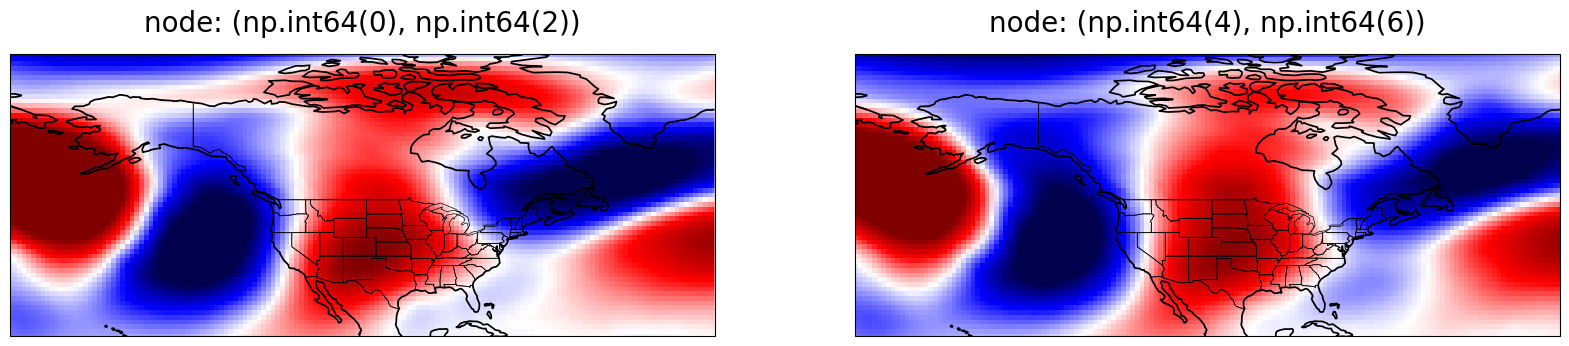

In [10]:
# ------------------------------------------------------------
# Map plot of a single transition (two consecutive days)
# FIXES:
#   - uses cfeature.BORDERS (not cf.BORDERS)
#   - plots edata on the 2nd panel (you had sdata twice)
#   - keeps 1D lat/lon arrays separate from the 2D meshgrid
#   - robust lon conversion to [-180, 180]
#   - reshapes data using (nlat, nlon) consistently
#   - adds bounds checks for idx / idx+1
# ------------------------------------------------------------

# ------------------------------------------------------------
# Set up 1D lat/lon arrays (subset) and convert lon to [-180, 180]
# ------------------------------------------------------------
ds_sub = dataset.sel(lat=latSlice, lon=lonSlice)

lats_1d = ds_sub.lat.values
lons_1d = ds_sub.lon.values

# convert to [-180, 180]
lons_1d = ((lons_1d + 180) % 360) - 180

# 2D meshgrid for plotting
LONS, LATS = np.meshgrid(lons_1d, lats_1d)

nlat = len(lats_1d)
nlon = len(lons_1d)

# ------------------------------------------------------------
# Set up figure + axes
# ------------------------------------------------------------
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(20, 10))
axs = []

axs.append(plt.subplot2grid((1, 2), (0, 0), rowspan=1, colspan=1, projection=proj))
axs.append(plt.subplot2grid((1, 2), (0, 1), rowspan=1, colspan=1, projection=proj))

# Background features
for ax in axs:
    ax.set_extent([-180, -30, 20, 80], crs=proj)
    ax.coastlines(resolution="110m", color="k", linewidth=1.25, zorder=10)
    ax.margins(x=0, y=0)
    ax.add_feature(cfeature.STATES, facecolor="none", edgecolor="k", linewidth=0.5, zorder=10)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="k", zorder=10)

# ------------------------------------------------------------
# Pick the transition index (in grouped transitions space)
# ------------------------------------------------------------
t_idx = 1247  # transition index in "run space" (i.e., groupedNeuronList / transitions_list indexing)

# run lengths for each consecutive regime
run_lengths = [sum(1 for _ in g) for _, g in itertools.groupby(neuronList)]

# convert transition index -> day index of last day in the start-run
idx = int(np.sum(run_lengths[:t_idx + 1]) - 1)

# bounds check
if idx < 0 or idx + 1 >= len(dataarray):
    raise IndexError(f"Computed idx={idx} is out of range for dataarray length={len(dataarray)}")

# ------------------------------------------------------------
# Extract fields for the two days
# ------------------------------------------------------------
sdata = np.asarray(dataarray[idx]).reshape((nlat, nlon))
edata = np.asarray(dataarray[idx + 1]).reshape((nlat, nlon))

# ------------------------------------------------------------
# Plot the two days
# ------------------------------------------------------------
axs[0].pcolormesh(
    LONS, LATS, sdata,
    vmin=minimum_weight, vmax=maximum_weight,
    cmap="seismic", shading="nearest", transform=proj
)
axs[0].set_title(f"node: {neuronList[idx]}", fontsize=20, y=1.05)

axs[1].pcolormesh(
    LONS, LATS, edata,   # FIX: use edata here
    vmin=minimum_weight, vmax=maximum_weight,
    cmap="seismic", shading="nearest", transform=proj
)
axs[1].set_title(f"node: {neuronList[idx + 1]}", fontsize=20, y=1.05)

plt.show()

In [11]:
# ------------------------------------------------------------
# Max outgoing transition probability per node (subset >=3-day)
# Robust against missing node_nums entries and empty dicts
# ------------------------------------------------------------

tProbs = subset_transitionProbs

avg_maxprob = 0.0
global_max = 0.0
global_min = 1.0
count_over = 0
n_valid = 0  # number of nodes with at least one outgoing transition

for s, out_dict in tProbs.items():
    # skip nodes with no outgoing transitions
    if not out_dict:
        continue

    # destination with maximum probability
    en = max(out_dict, key=out_dict.get)
    m = float(out_dict[en])

    # track global stats
    if m > global_max:
        global_max = m
    if m < global_min:
        global_min = m

    if m >= 0.40:
        count_over += 1

    # safe node number lookup (fallback to coords if missing)
    s_label = node_nums.get(s, s)
    e_label = node_nums.get(en, en)

    print(f"{s_label} -> {e_label}: {m}")

    avg_maxprob += m
    n_valid += 1

avg_maxprob = avg_maxprob / n_valid if n_valid > 0 else float("nan")

# Optional summary prints
# print(f"max: {global_max}")
# print(f"min: {global_min}")
# print(f"count >= 0.40: {count_over}")
# print(f"avg max-prob per node: {avg_maxprob}")

34 -> 34: 0.7900894700619409
35 -> 35: 0.615606936416185
36 -> 36: 0.6072931276297335
37 -> 37: 0.7681744749596123
29 -> 29: 0.6422155688622755
30 -> 30: 0.4276729559748428
31 -> 31: 0.5294117647058824
32 -> 32: 0.3197278911564626
33 -> 33: 0.654424040066778
23 -> 23: 0.6743362831858407
24 -> 24: 0.42857142857142855
25 -> 25: 0.5633187772925764
26 -> 26: 0.6223776223776224
27 -> 27: 0.45161290322580644
28 -> 28: 0.612565445026178
16 -> 16: 0.7826552462526767
17 -> 17: 0.4666666666666667
18 -> 18: 0.5793103448275863
19 -> 19: 0.6208651399491094
20 -> 20: 0.6373626373626373
21 -> 21: 0.4222222222222222
22 -> 22: 0.7603092783505154
10 -> 10: 0.6504347826086957
11 -> 11: 0.4745762711864407
12 -> 12: 0.6143790849673203
13 -> 13: 0.6466666666666666
14 -> 14: 0.5056818181818182
15 -> 15: 0.6481178396072013
5 -> 5: 0.634508348794063
6 -> 6: 0.38064516129032255
7 -> 7: 0.5083798882681564
8 -> 8: 0.48026315789473684
9 -> 9: 0.6125
1 -> 1: 0.8048780487804879
2 -> 2: 0.6029629629629629
3 -> 3: 0.6

In [12]:
# ------------------------------------------------------------
# Annual / subset (>=3-day) significance
# Toggle self-significance on/off here:
#   - include_self_sig = True  -> test self + adjacent; return significant_self_nodes
#   - include_self_sig = False -> test adjacent only; significant_self_nodes = empty set
# ------------------------------------------------------------

iters = 1000
percentile = 0.95

include_self_sig = True   # <<< TOGGLE THIS (True / False)

# ------------------------------------------------------------
# Build candidate destination lists depending on toggle
# ------------------------------------------------------------
if include_self_sig:
    # self + adjacent (dist in {0,1})
    neighbors_candidates = precompute_neighbors_with_self(node_indices)
else:
    # adjacent only (dist == 1)
    neighbors_candidates = {
        node: [node_end for node_end in node_indices if calc_transition_distance(node, node_end) == 1]
        for node in node_indices
    }

# ------------------------------------------------------------
# Compute significance
# ------------------------------------------------------------
sig_edges_coord, sig_self_nodes = calc_transition_significance_with_self(
    counts_dict=subset_transitionCounts,
    nodes=node_indices,
    percentile=percentile,
    iters=iters,
    neighbors_with_self=neighbors_candidates
)

# ------------------------------------------------------------
# Keep only adjacent significant edges (dist==1)
# (Even when include_self_sig=True, this removes any non-adjacent if they existed.)
# ------------------------------------------------------------
significant_transitions = [
    (s, e) for (s, e) in sig_edges_coord
    if calc_transition_distance(s, e) == 1
]

# Self-significant nodes (empty if include_self_sig=False)
significant_self_nodes = sig_self_nodes if include_self_sig else set()

# ------------------------------------------------------------
# Optional summaries
# ------------------------------------------------------------
# print("Significant edges (adjacent only):", len(significant_transitions))
# print("Self-significant nodes:", len(significant_self_nodes))

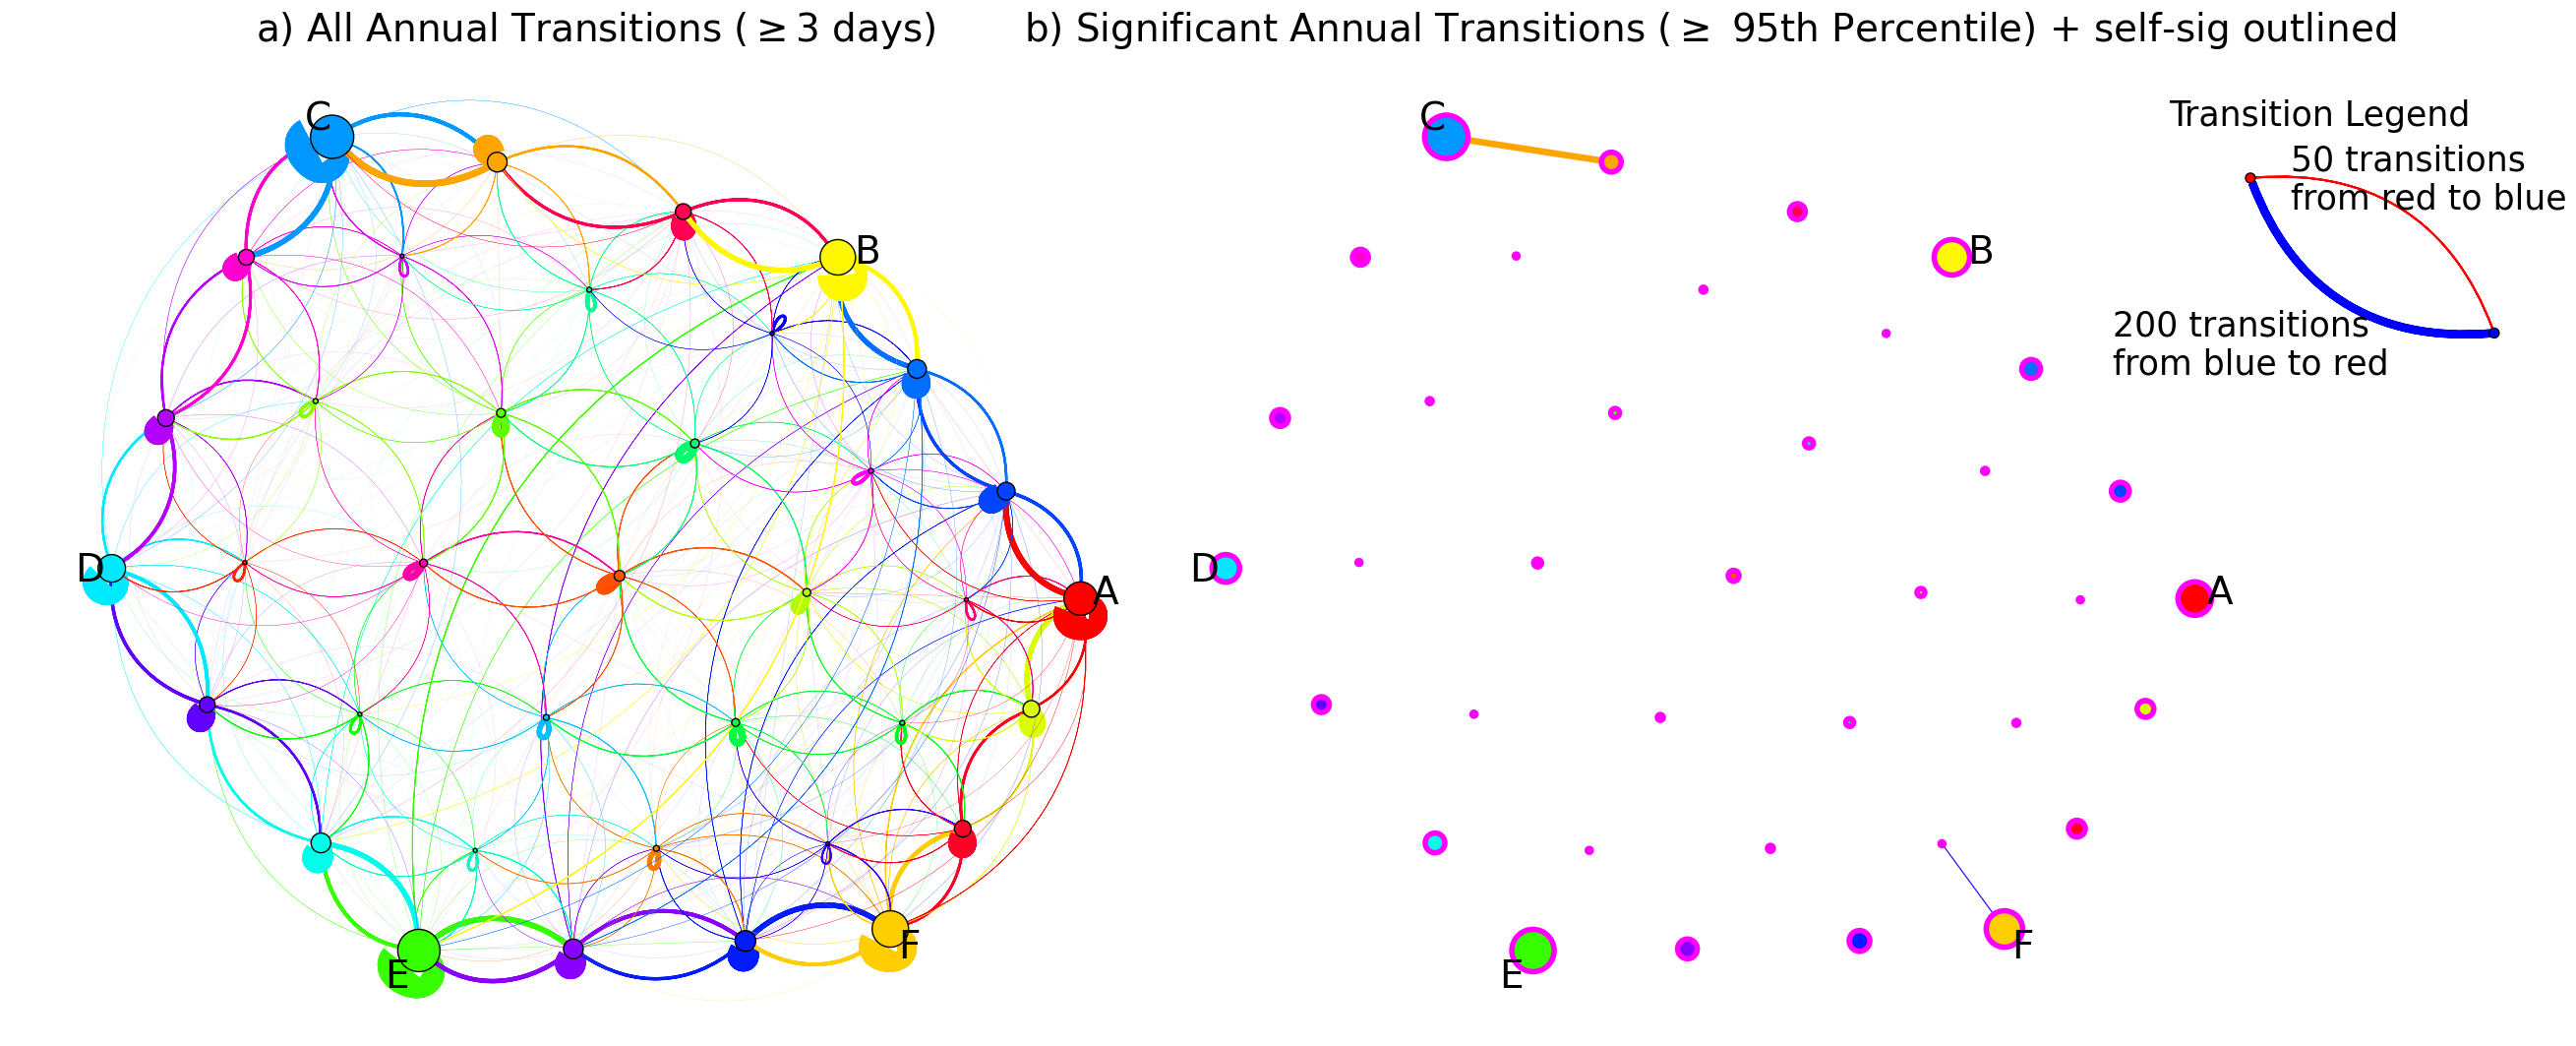

In [13]:
# ------------------------------------------------------------
# ANNUAL (3-day+) TRANSITIONS: 2-panel plot (1 row x 2 cols)
# MATCHING your seasonal "happy" style:
#   - transparent subplot backgrounds
#   - NO example nodes/edges added into the real plots
#   - example transition plotted ONCE on a global figure axis (outside panels)
#   - TOP-LEVEL TOGGLE for self-significance outlines on panel (b)
#
# Requires:
#   sub_transitions, sub_tcounts
#   subset_transitionCounts
#   significant_transitions        # list of ((row,col),(row,col)) for dist==1
#   significant_self_nodes         # set of (row,col) with significant self-transition
#   y (Sammon coords), color_list, node_indices
# ------------------------------------------------------------

# -------------------------------
# TOGGLE SELF-SIGNIFICANCE OUTLINES (panel b only)
# -------------------------------
show_self_sig = True

# Precompute node->index for speed/safety
node_to_idx = {node: i for i, node in enumerate(node_indices)}

fig, axs = plt.subplots(1, 2, figsize=(30, 13))

# Make each subplot background transparent
for ax in axs.flat:
    ax.set_facecolor("none")
    ax.patch.set_alpha(0.0)

# ============================================================
# Panel (a): All transitions (subset >=3-day)  -- REAL ONLY
# ============================================================
ax = axs[0]

n_vertices = len(node_indices)

edges = [(node_to_idx[tuple(s)], node_to_idx[tuple(e)]) for s, e in sub_transitions]
edgeWeights = [int(w) for w in sub_tcounts]

vertexWeights = [sum(subset_transitionCounts.get(n, {}).values()) for n in node_indices]
vertexColors = list(color_list)

edgeColors = [color_list[s] for s, e in edges] if len(edges) > 0 else []

g_a = ig.Graph(n_vertices, edges)
layout_a = ig.Layout(coords=y)

ax.set_title(r"a) All Annual Transitions ($\geq 3$ days)", fontsize=28)

ig.plot(
    g_a,
    target=ax,
    layout=layout_a,
    vertex_size=[v * 0.03 for v in vertexWeights],
    vertex_color=vertexColors,
    vertex_frame_color=["#000000"] * n_vertices,
    vertex_frame_width=[1] * n_vertices,
    edge_width=[w * 0.03 for w in edgeWeights],
    edge_color=edgeColors,
)

# ============================================================
# Panel (b): Significant transitions only (adjacent, subset >=3-day)
#   + optional self-sig outlines
# ============================================================
ax = axs[1]

sig_set = set((tuple(a), tuple(b)) for (a, b) in significant_transitions)

sig_edges = []
sig_edgeWeights = []

# Pull significant edges from sub_transitions so weights align
for i, (s, e) in enumerate(sub_transitions):
    s_t = tuple(s)
    e_t = tuple(e)
    if (s_t, e_t) in sig_set:
        sig_edges.append((node_to_idx[s_t], node_to_idx[e_t]))
        sig_edgeWeights.append(int(sub_tcounts[i]))

vertexWeights_b = [sum(subset_transitionCounts.get(n, {}).values()) for n in node_indices]
vertexColors_b = list(color_list)

edgeColors_b = [color_list[s] for s, e in sig_edges] if len(sig_edges) > 0 else []

# Self-significant node outlines (toggle)
if show_self_sig:
    vertex_frame_color = ["#ff00ff" if n in significant_self_nodes else "#000000" for n in node_indices]
    vertex_frame_width = [4 if n in significant_self_nodes else 1 for n in node_indices]
    title_suffix = " + self-sig outlined"
else:
    vertex_frame_color = ["#000000"] * n_vertices
    vertex_frame_width = [1] * n_vertices
    title_suffix = ""

g_b = ig.Graph(n_vertices, sig_edges)
layout_b = ig.Layout(coords=y)

ax.set_title(r"b) Significant Annual Transitions ($\geq$ 95th Percentile)" + title_suffix, fontsize=28)

ig.plot(
    g_b,
    target=ax,
    layout=layout_b,
    vertex_size=[v * 0.03 for v in vertexWeights_b],
    vertex_color=vertexColors_b,
    vertex_frame_color=vertex_frame_color,
    vertex_frame_width=vertex_frame_width,
    edge_width=[w * 0.03 for w in sig_edgeWeights],
    edge_color=edgeColors_b,
)

# ------------------------------------------------------------
# GLOBAL figure-level axis for the example (OUTSIDE the panels)
#   - keeps scale stable (igraph plot)
#   - matches your seasonal placement concept
# ------------------------------------------------------------
example_ax = fig.add_axes([0.83, 0.58, 0.15, 0.22])  # [left, bottom, width, height] in FIGURE coords
example_ax.set_axis_off()

# Standalone example graph (not using real edges)
g_ex = ig.Graph(2, [(0, 1), (1, 0)])
layout_ex = ig.Layout(coords=[[15, 45], [45, 15]])

vertexWeights_ex = [350, 350]
vertexColors_ex  = ["#ff0000", "#0000ff"]  # red, blue

# Match your original annual legend numbers: blue->red=200, red->blue=50
# With nodes [0]=red, [1]=blue:
#   (1->0) is blue->red  = 200
#   (0->1) is red->blue  = 50
edgeWeights_ex = [50, 200]                 # (0->1)=50, (1->0)=200
edgeColors_ex  = ["#ff0000", "#0000ff"]    # red edge, blue edge

ig.plot(
    g_ex,
    target=example_ax,
    layout=layout_ex,
    vertex_size=[v * 0.03 for v in vertexWeights_ex],
    vertex_color=vertexColors_ex,
    edge_width=[w * 0.03 for w in edgeWeights_ex],
    edge_color=edgeColors_ex,
)

# Example annotation (data coords inside the inset axis)
example_ax.text(-2, 7, "200 transitions\nfrom blue to red", fontsize=25)
example_ax.text(20, 39, "50 transitions\nfrom red to blue", fontsize=25)
example_ax.text(5, 55, "Transition Legend", fontsize=25)

# ------------------------------------------------------------
# Labels (looped version)
# ------------------------------------------------------------
label_specs = [
    ("A",   54,  -4, 28),
    ("B",   27,  42, 28),
    ("C",  -35,  60, 28),
    ("D",  -61,  -1, 28),
    ("E",  -26, -56, 28),
    ("F",   32, -52, 28),
]

# apply to every seasonal subplot axis
for ax in axs.flat:
    for txt, x0, y0, fs in label_specs:
        ax.text(x0, y0, txt, fontsize=fs)

plt.subplots_adjust(wspace=-0.05)
#plt.savefig("Annual_transitions_3day_all_and_sig.pdf", transparent=True, bbox_inches="tight")
plt.show()

In [14]:
# ------------------------------------------------------------
# Seasonal significance computation with OPTIONAL self-significance
# ------------------------------------------------------------

iters = 1000
percentile = 0.95

include_self_sig = True   # <<< TOGGLE THIS (True / False)

# Candidate destinations:
#   - include_self_sig=True  -> dist in {0,1}
#   - include_self_sig=False -> dist == 1 only
if include_self_sig:
    neighbors_candidates = precompute_neighbors_with_self(node_indices)
else:
    neighbors_candidates = {
        node: [node_end for node_end in node_indices if calc_transition_distance(node, node_end) == 1]
        for node in node_indices
    }

DJF_sig_edges, DJF_sig_wts, DJF_frame_c, DJF_frame_w, DJF_selfsig = build_sig_plot_data(
    counts_dict=DJF_tcounts,
    nodes=node_indices,
    trans_universe=sub_transitions,
    percentile=percentile,
    iters=iters,
    neighbors_with_self=neighbors_candidates
)

MAM_sig_edges, MAM_sig_wts, MAM_frame_c, MAM_frame_w, MAM_selfsig = build_sig_plot_data(
    counts_dict=MAM_tcounts,
    nodes=node_indices,
    trans_universe=sub_transitions,
    percentile=percentile,
    iters=iters,
    neighbors_with_self=neighbors_candidates
)

JJA_sig_edges, JJA_sig_wts, JJA_frame_c, JJA_frame_w, JJA_selfsig = build_sig_plot_data(
    counts_dict=JJA_tcounts,
    nodes=node_indices,
    trans_universe=sub_transitions,
    percentile=percentile,
    iters=iters,
    neighbors_with_self=neighbors_candidates
)

SON_sig_edges, SON_sig_wts, SON_frame_c, SON_frame_w, SON_selfsig = build_sig_plot_data(
    counts_dict=SON_tcounts,
    nodes=node_indices,
    trans_universe=sub_transitions,
    percentile=percentile,
    iters=iters,
    neighbors_with_self=neighbors_candidates
)

# If self significance is OFF, force outlines to be neutral + empty sets
if not include_self_sig:
    DJF_frame_c = ["#000000"] * len(node_indices)
    DJF_frame_w = [1] * len(node_indices)
    DJF_selfsig = set()

    MAM_frame_c = ["#000000"] * len(node_indices)
    MAM_frame_w = [1] * len(node_indices)
    MAM_selfsig = set()

    JJA_frame_c = ["#000000"] * len(node_indices)
    JJA_frame_w = [1] * len(node_indices)
    JJA_selfsig = set()

    SON_frame_c = ["#000000"] * len(node_indices)
    SON_frame_w = [1] * len(node_indices)
    SON_selfsig = set()

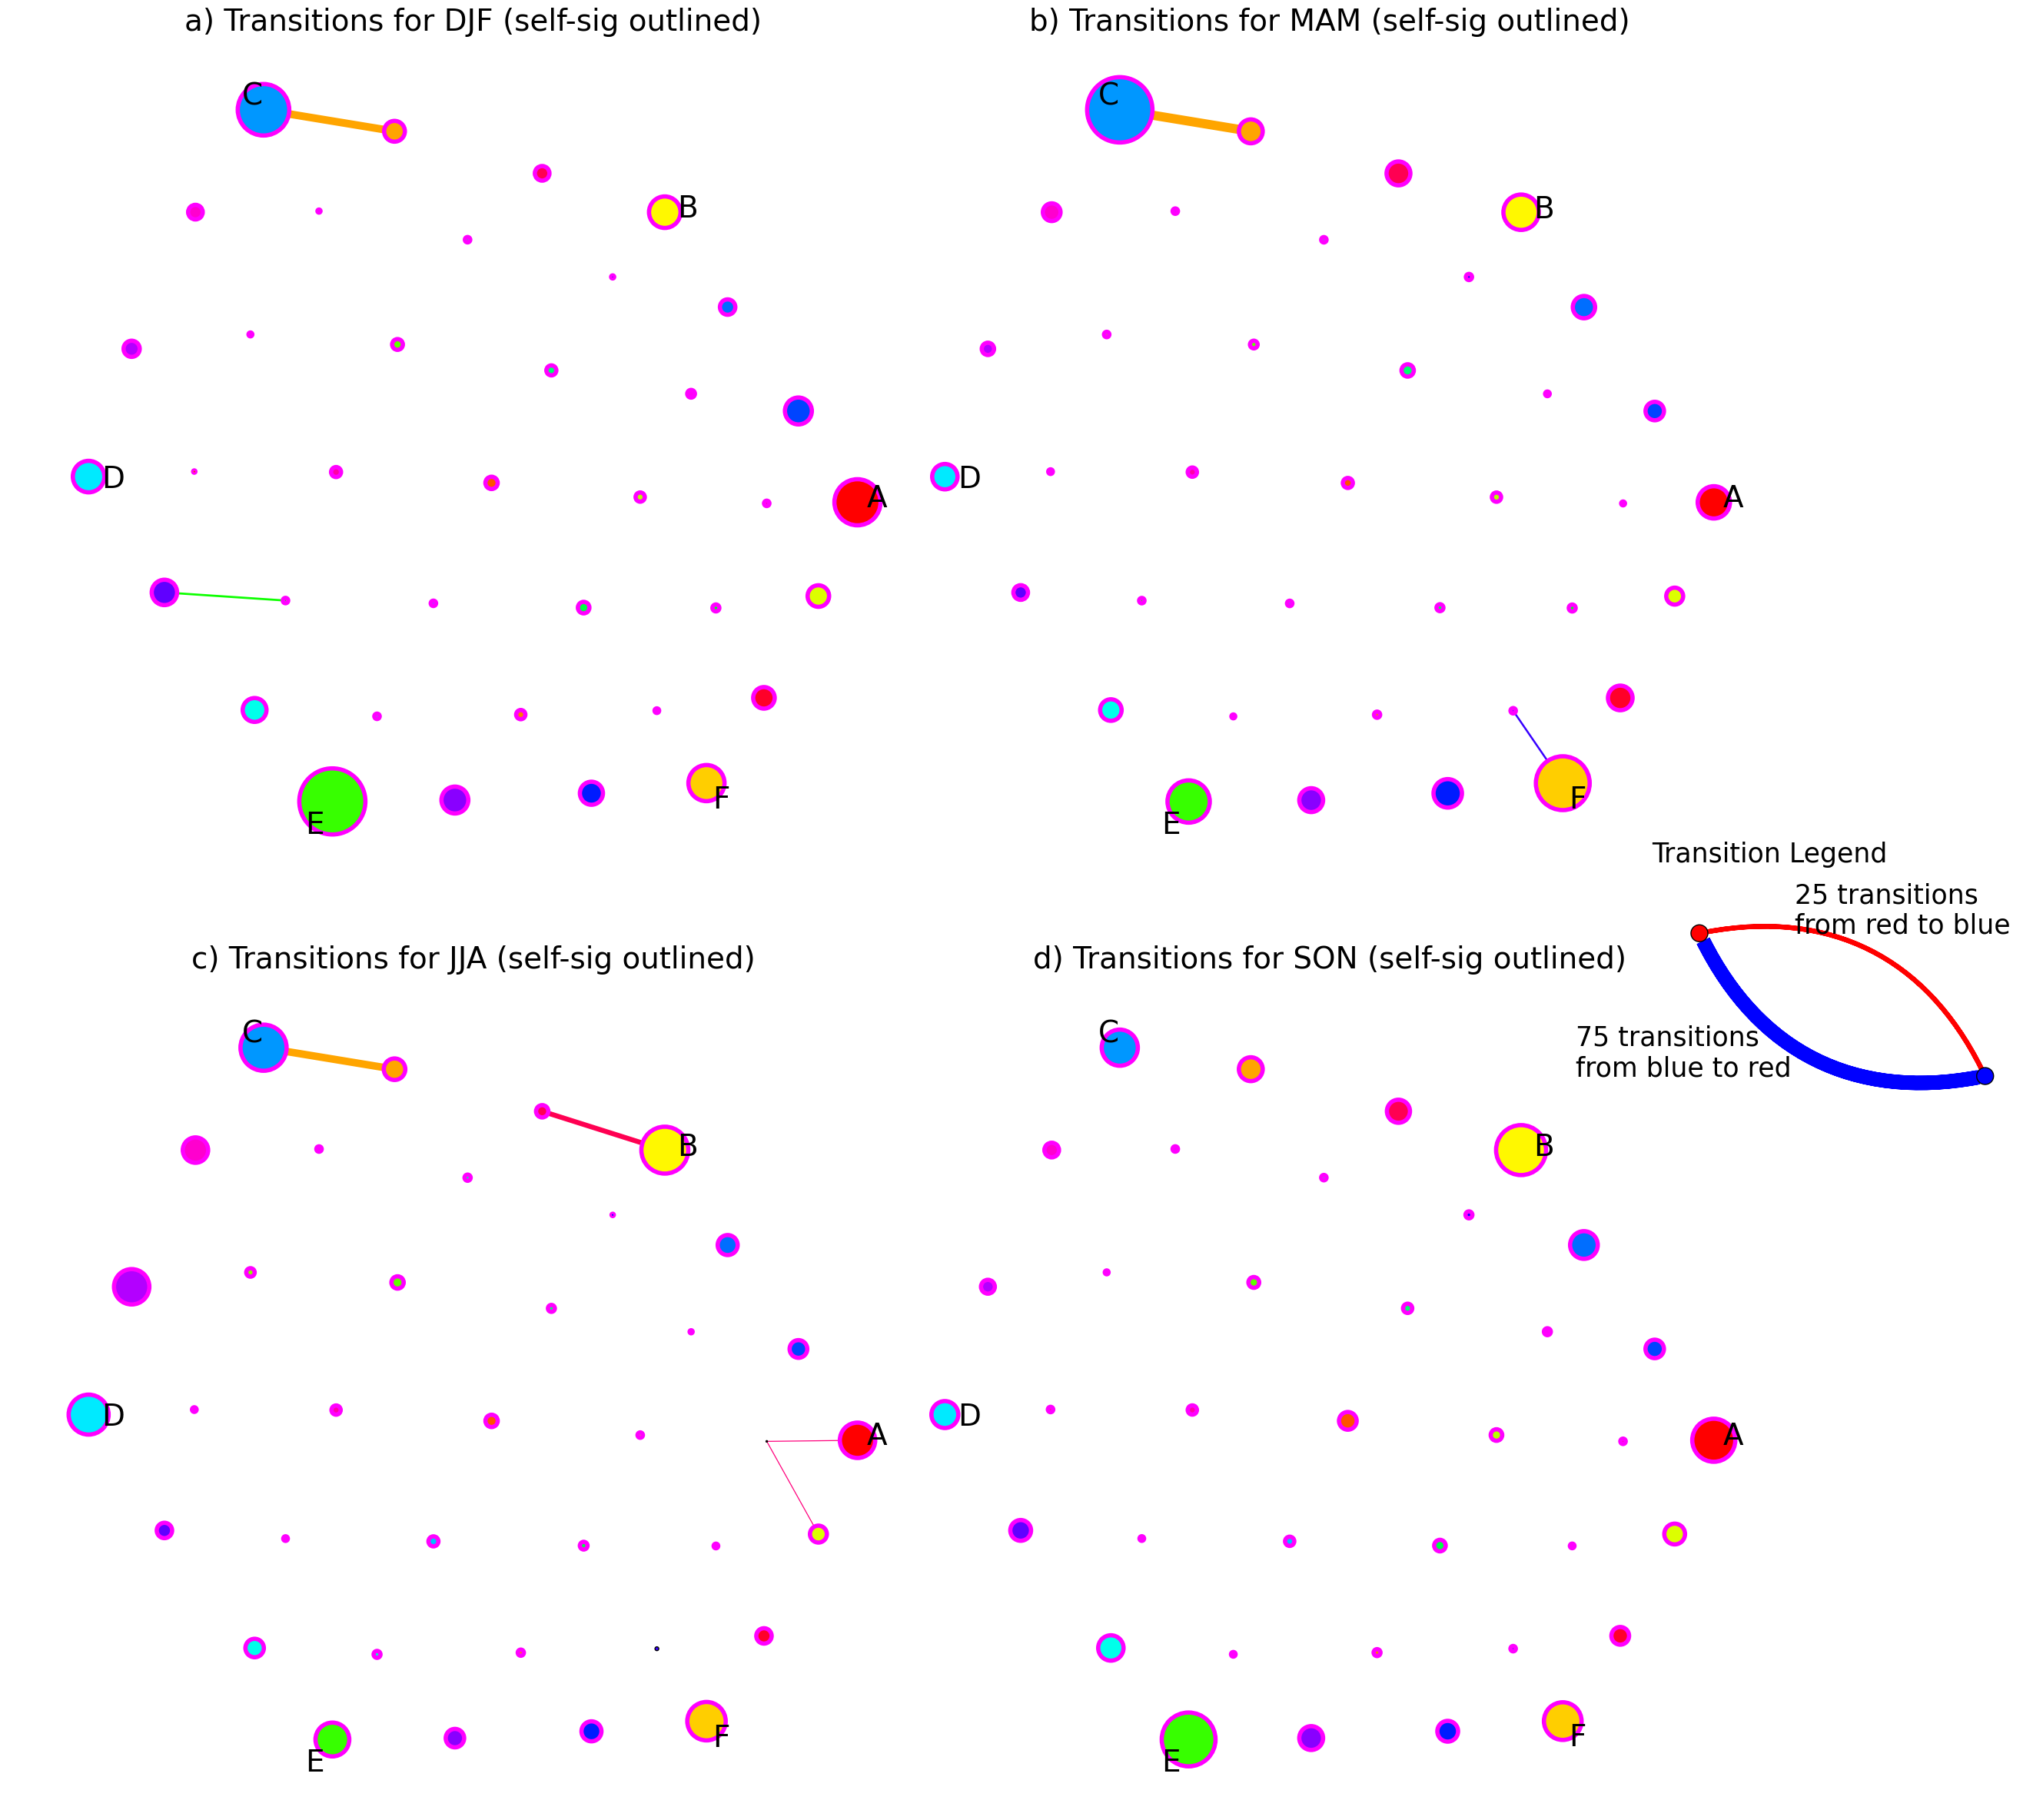

In [15]:
# ------------------------------------------------------------
# Seasonal significant transitions (2x2) with:
#   - safe edges/weights (do NOT mutate originals)
#   - OPTIONAL self-significance shown via vertex outlines (TOGGLE BELOW)
#   - example transition plotted ONCE on a global figure axis (outside loop)
# ------------------------------------------------------------

show_self_sig = True

seasonal_transitions = [
    ("DJF", DJF_sig_edges, DJF_sig_wts, DJF_tcounts, DJF_frame_c, DJF_frame_w),
    ("MAM", MAM_sig_edges, MAM_sig_wts, MAM_tcounts, MAM_frame_c, MAM_frame_w),
    ("JJA", JJA_sig_edges, JJA_sig_wts, JJA_tcounts, JJA_frame_c, JJA_frame_w),
    ("SON", SON_sig_edges, SON_sig_wts, SON_tcounts, SON_frame_c, SON_frame_w),
]

plbls = ['a) ', 'b) ', 'c) ', 'd) ']

fig, axs = plt.subplots(2, 2, figsize=(30, 30))

# Make each subplot background transparent
for ax in axs.flat:
    ax.set_facecolor("none")          # transparent axes background
    ax.patch.set_alpha(0.0)           # ensure fully transparent

# ------------------------------------------------------------
# REAL seasonal plots (no example nodes/edges added)
# ------------------------------------------------------------
for i, (season_name, base_edges, base_wts, season_counts, frame_c, frame_w) in enumerate(seasonal_transitions):
    ax = axs[i // 2, i % 2]

    n_vertices = len(node_indices)

    edges = list(base_edges)
    edgeWeights = [int(w) for w in base_wts]

    vertexWeights = [sum(season_counts.get(n, {}).values()) for n in node_indices]
    vertexColors = list(color_list)

    edgeColors = [color_list[s] for s, e in edges] if len(edges) > 0 else []

    if show_self_sig:
        frame_c_plot = list(frame_c)
        frame_w_plot = list(frame_w)
        title_suffix = " (self-sig outlined)"
    else:
        frame_c_plot = ["#000000"] * len(node_indices)
        frame_w_plot = [1] * len(node_indices)
        title_suffix = ""

    ax.set_title(f"{plbls[i]}Transitions for {season_name}{title_suffix}", fontsize=28)

    g_real = ig.Graph(n_vertices, edges)
    layout_real = ig.Layout(coords=y)

    ig.plot(
        g_real,
        target=ax,
        layout=layout_real,
        vertex_size=[v * 0.18 for v in vertexWeights],
        vertex_color=vertexColors,
        vertex_frame_color=frame_c_plot,
        vertex_frame_width=frame_w_plot,
        edge_width=[w * 0.18 for w in edgeWeights],
        edge_color=edgeColors,
    )

# ------------------------------------------------------------
# GLOBAL figure-level axis for the example (OUTSIDE the loop)
# ------------------------------------------------------------
example_ax = fig.add_axes([0.8, 0.40, 0.20, 0.10])  # [left, bottom, width, height] in fig coords
example_ax.set_axis_off()

# ------------------------------------------------------------
# Build a STANDALONE example graph (NOT using seasonal edges)
# ------------------------------------------------------------
g_ex = ig.Graph(2, [(0, 1), (1, 0)])     # 2 nodes, 2 directed edges
layout_ex = ig.Layout(coords=[[10, 40], [40, 10]])

vertexWeights_ex = [125, 125]
vertexColors_ex  = ["#ff0000", "#0000ff"]   # red, blue

edgeWeights_ex   = [25, 75]                 # (0->1)=25, (1->0)=75
edgeColors_ex    = ["#ff0000", "#0000ff"]   # red edge, blue edge

ig.plot(
    g_ex,
    target=example_ax,
    layout=layout_ex,
    vertex_size=[v * 0.18 for v in vertexWeights_ex],
    vertex_color=vertexColors_ex,
    edge_width=[w * 0.18 for w in edgeWeights_ex],
    edge_color=edgeColors_ex,
)

# Example annotation (data coords, matches your original style)
example_ax.text(-3, 10, "75 transitions\nfrom blue to red", fontsize=25)
example_ax.text(20, 40, "25 transitions\nfrom red to blue", fontsize=25)
example_ax.text(5, 55, "Transition Legend", fontsize=25)
#example_ax.plot([-10, -10, -10, -10, 30], [68, 47, 47, 68, 68], color="k")

# ------------------------------------------------------------
# Labels (looped version)
# ------------------------------------------------------------
label_specs = [
    ("A",   54,  -4, 28),
    ("B",   27,  42, 28),
    ("C",  -35,  60, 28),
    ("D",  -55,  -1, 28),
    ("E",  -26, -56, 28),
    ("F",   32, -52, 28),
]

# apply to every seasonal subplot axis
for ax in axs.flat:
    for txt, x0, y0, fs in label_specs:
        ax.text(x0, y0, txt, fontsize=fs)


plt.subplots_adjust(wspace=-0.08, hspace=0.12)
#plt.savefig("Seasonal_transitions.pdf", transparent=True, bbox_inches='tight')
plt.show()